# A Detailed Overview of Using MAGNET

Start by importing all the packages and tools we'll need:

In [13]:
import pandas as pd
import porespy as ps
import openpnm as op
import numpy as np
import scipy.ndimage as spim
from skimage.morphology import square, cube
import matplotlib.pyplot as plt

edt = ps.tools.get_edt()

## Set simulation parameters

In [8]:
np.random.seed(10)
export = False
fill_blind_pores = True
padding = None
l_max = None
bw = None
endpoints = True
name = 'Bentheimer'
res = 5.82e-6
Kx, Ky, Kz, Kavg = [], [], [], []
porosity = []

# Import and prepare image

In [ ]:
f = "bentheimer.npz"
imb = np.load(f)['arr_0']
imb = ps.filters.fill_invalid_pores(imb, conn='min')
imb = ps.filters.trim_floating_solid(imb, conn='min', incl_surface=True)
im = imb
eps = ps.metrics.porosity(im)
porosity.append(eps)
print(f'porosity: {eps*100}%')

porosity: 19.9100376%


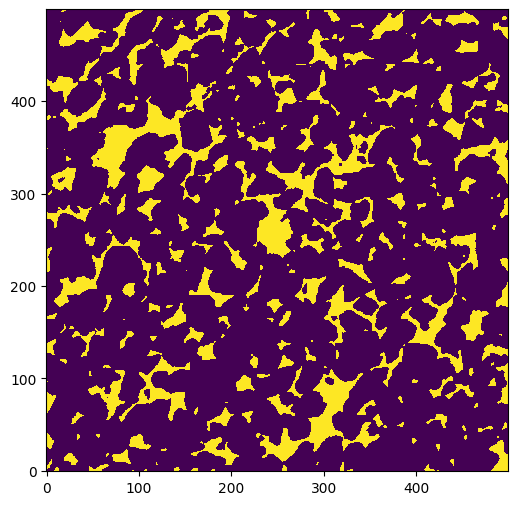

In [18]:
fig, ax = plt.subplots(figsize=[6, 6])
ax.imshow(im[..., 250], origin='lower', interpolation='none');

## Get Skeleton

In [19]:
sk, im = ps.networks.skeleton(im)
labels, N = spim.label(sk, structure=ps.tools.ps_rect(3, 3))
values, counts = np.unique(labels, return_counts=True)
if N > 1:
    print(f"There are {N} separated segments in the skeleton")
    print(f"Their sizes are {counts[1:]}")

## Compute Distance Transform

In [20]:
dt = edt(im)

## Find junctions and end points on skeleton

In [ ]:
juncs, endpts = ps.networks.find_junctions(sk)
merge_nearby_juncs
find_throat_junctions 
pores, throats = ps.networks.partition_skeleton(sk, juncs + endpts, dt)
new_juncs, pores, new_throats =\
    ps.networks.find_throat_junctions(im=im, pores=pores, throats=throats, dt=dt)

## Insert pores at junction points

In [21]:
pts = (pores + new_juncs) > 0
fbd = ps.networks.insert_pore_bodies(sk, dt, pts)

NameError: name 'pores' is not defined

## convert spheres to network dictionary

In [ ]:
net = ps.networks.spheres_to_network(
    sk=sk,
    dt=dt,
    fbd=fbd,
    voxel_size=res,
    boundary_width=0,
)

AttributeError: module 'porespy.networks' has no attribute 'spheres_to_network'

## Import network to openpnm

In [12]:
net = op.io.network_from_porespy(net)
net['pore.diameter'] = net['pore.radius']*2
net['throat.diameter'] = net['throat.radius']*2

NameError: name 'net' is not defined

## Check network health

In [ ]:
h = op.utils.check_network_health(net)
op.topotools.trim(net, pores=np.append(h['disconnected_pores'], h['isolated_pores']))
h = op.utils.check_network_health(net)


## Add geometry models

In [ ]:
geo = op.models.collections.geometry.cubes_and_cuboids.copy()
del geo['pore.diameter'], geo['throat.diameter']
net['pore.diameter'] = net['pore.diameter'].copy()
net['throat.diameter'] = net['throat.diameter'].copy()
net.add_model_collection(geo)
net.regenerate_models()

## Add phase

In [ ]:
phase = op.phase.Phase(network=net)
phase['pore.viscosity'] = 1e-3

## Define physics

In [ ]:
phys = op.models.collections.physics.basic.copy()
phase.add_model_collection(phys)
phase.regenerate_models()

## Setup stokes flow simulation to estimate permeability

In [ ]:
Pin = 5e-6
Pout = 0
A = (im.shape[0]*im.shape[1]) * res**2
L = im.shape[1] * res
mu = phase['pore.viscosity'].max()

## label boundary pores

In [ ]:
xmin = net.coords[:, 0] <= net.coords[:, 0].max()*0.02
xmax = net.coords[:, 0] >= net.coords[:, 0].max()*0.98
flow_x = op.algorithms.StokesFlow(network=net, phase=phase)
flow_x.set_value_BC(pores=xmin, values=Pin)
flow_x.set_value_BC(pores=xmax, values=Pout)
flow_x.run()

Q_x = flow_x.rate(pores=xmin, mode='group')[0]
K_x = Q_x * L * mu / (A * (Pin - Pout))/0.98e-12*1000
print(f'K_x is: {K_x:.2f} mD')

ymin = net.coords[:, 1] <= net.coords[:, 1].max()*0.02
ymax = net.coords[:, 1] >= net.coords[:, 1].max()*0.98
flow_y = op.algorithms.StokesFlow(network=net, phase=phase)
flow_y.set_value_BC(pores=ymin, values=Pin)
flow_y.set_value_BC(pores=ymax, values=Pout)
flow_y.run()

Q_y = flow_y.rate(pores=ymin, mode='group')[0]
K_y = Q_y * L * mu / (A * (Pin - Pout))/0.98e-12*1000
print(f'K_y is: {K_y:.2f} mD')

zmin = net.coords[:, 2] <= net.coords[:, 2].max()*0.02
zmax = net.coords[:, 2] >= net.coords[:, 2].max()*0.98
flow_z = op.algorithms.StokesFlow(network=net, phase=phase)
flow_z.set_value_BC(pores=zmin, values=Pin)
flow_z.set_value_BC(pores=zmax, values=Pout)
flow_z.run()

Q_z = flow_z.rate(pores=zmin, mode='group')[0]
K_z = Q_z * L * mu / (A * (Pin - Pout))/0.98e-12*1000
print(f'K_z is: {K_z:.2f} mD')

K = np.average([K_x, K_y, K_z])
print(f'K is: {K:.2f} mD')

Compared to the expected values:

In [ ]:
print('The expected permeability is 2490 mD')

Kx.append(K_x)
Ky.append(K_y)
Kz.append(K_z)
Kavg.append(K)

print(Kavg)

## Export

In [ ]:
if export:
    proj = net.project
    op.io.project_to_xdmf(proj, filename=name + '-network')